![Nuclio logo](https://cdn.prod.website-files.com/633b44aa19e0eb425d7e8c7f/63724d646ecb4bd4cbdf7440_LOGO%20NUCLIO%20DIGITAL%20SCHOOL-01-01-p-500.png)

## 1. Librerias & Google Drive

Para empezar carguemos esas librerias que nos hacen falta

In [ ]:
import tensorflow as tf
from tensorflow import keras as ks
from matplotlib import pyplot as plt
import numpy as np
import time
import datetime

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import src.utils as utils
import src.utils_plots as plots
import src.cifar10_labels as cifar10
import src.shape_tests as shapes
import src.train_test as train_test

cifar10_labels = cifar10.cifar10_labels
 

Incorporamos la carpeta de Google Drive para poder "guardar" nuestros modelos

1. Abrir barra lateral de Carpeta
2.  Hacer click en carpeta con logo de Google Drive


In [2]:
# Aquí iria el codigo para conectarse a Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Proyecto 0

## 2. Arquitectura de red del modelo - Proyecto 0


In [3]:
model = ks.Sequential()

model.add(ks.layers.Input((32,32,3)))

model.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu',
                           padding='same'))
model.add(ks.layers.MaxPooling2D((2, 2)))

model.add(ks.layers.Flatten())
model.add(ks.layers.Dense(32, activation='relu'))
model.add(ks.layers.Dense(10, activation='softmax'))


Para revisar un modelo, nos basta con llamar al método **.summary()** del modelo

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,402 (1.00 MB)

 Trainable params: 263,402 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizador, función error


In [5]:
model.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Preparamos los datos

Cargamos los datos de CIFAR10 de lo que os paso por Google Drive

https://drive.google.com/file/d/18uT-D7Ak2bj_SZ0nKdXLYDYuKVaaFfzJ/view?usp=sharing

Subid el archivo `cifar-10-batches-py.tar.gz` a vuestro Google Drive, a una carpeta conocida que luego tendréis que adaptar.

Luego pasaremos a cargarlos y post-procesarlos para tener un dataset idéntico al que tendrías cargado directamente de Keras

Nota: cambiad el PATH del comando `! cp` que apunte donde esté el `cifar-10-batches-py.tar.gz` localizado

In [6]:
# ! cp /content/drive/MyDrive/00_Nuclio_DS_Master/cifar-10-batches-py.tar.gz /content/
# ! tar -xzf /content/cifar-10-batches-py.tar.gz -C /content/

# ! ls -la /content
# ! ls -la /content/cifar-10-batches-py


In [7]:
data_dir = "cifar-10-batches-py/"

In [8]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)


In [9]:
# Validamos el resultado

shapes.validar_shape(x_train_rows,y_train,'train')
shapes.validar_shape(x_test_rows,y_test,'test')

Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [ ]:
x_train_test = train_test.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

shapes.validar_shape(x_train,y_train,'train')
shapes.validar_shape(x_test,y_test,'test')


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [11]:
scaled_values = train_test.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

shapes.validar_shape(x_train_scaled,y_train,'train')
shapes.validar_shape(x_test_scaled,y_test,'test')


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


Obtenemos un array con todas las labels de CIFAR10

In [15]:
print('Number of labels: %s' % len(cifar10.cifar10_labels))

Number of labels: 10


Pintemos una muestra de las imagenes del dataset CIFAR10, a ver si se parece en algo a lo que esperamos.
Primero, vemos que tipos de datos tengo, después mapeamos esas matrices en una escala de grises utilizando el método **.get_cmap()** de PlotLy con los nueve primeros números del dataset.

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


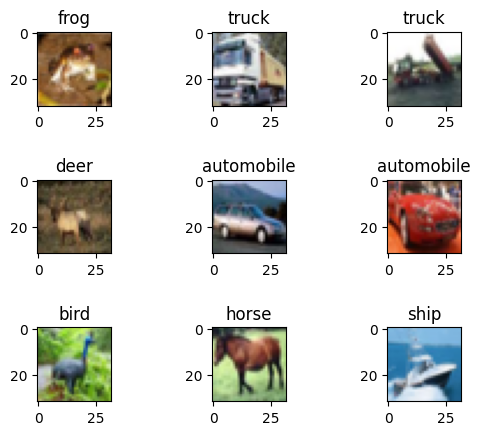

In [ ]:
# Pintemos una muestra de las las imagenes del dataset MNIST

print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

plots.cmap_muestras(x_train,y_train,cifar10_labels)

for i in range(9):

    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
    plt.title(utils.cifar10_labels[y_train[i]])

plt.subplots_adjust(hspace = 1)
plt.show()

Como vamos a querer ir haciendo validación a la vez que entrenamos (muy practico)

In [19]:
x_val_scaled = x_train_scaled[-10000:]
y_val = y_train[-10000:]

x_train_scaled = x_train_scaled[:-10000]
y_train = y_train[:-10000]


Cuando añadimos convoluciones, necesitamos "pre-tratar los datos", porque **la convolución espera una matriz de 4 campos** (más parecido a "imagenes"), en el caso de MNIST. CIFAR10 ya tiene el shape adecuado, así que no tenemos que hacer nada, pero como siempre decimos: es mejor que comprobeis su tamaño.

Por eso, al salir de la Convolution, hay que hacer un Flatten, porque las capas FullDense esperan arrays, no matrices!!

Luego lo imprimimos para ver que todo está correcto

In [20]:
# Validamos el resultado
print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))
print('Validation: X=%s, y=%s' % (x_val_scaled.shape, y_val.shape))

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

Ya podemos ponernos a entrenar el modelo!! Ojo, que hemos de entrenar contra los datos convertidos al formato que espera la Convolution.

Empezaremos con 30 epocs, es decir, 30 pasadas completas del dataset (que a su vez sera con mini-batches internamente), fijando un batch de 64

El metodo .fit() nos permite, definir además si disponemos de varias CPUs, GPUs, y si queremos ir validando datos a cada fin de epoch.

In [36]:
t = time.perf_counter()

In [40]:
# history = model.fit(x_train_scaled, y_train, epochs=20,
#                  batch_size= 512, validation_data=(x_val_scaled, y_val))

history = model.fit(x_train_scaled, y_train, epochs=5,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4486 - loss: 1.5690 - val_accuracy: 0.4603 - val_loss: 1.5340
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4927 - loss: 1.4353 - val_accuracy: 0.5038 - val_loss: 1.4089
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5244 - loss: 1.3524 - val_accuracy: 0.5208 - val_loss: 1.3915
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5416 - loss: 1.3001 - val_accuracy: 0.5452 - val_loss: 1.3118
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5610 - loss: 1.2545 - val_accuracy: 0.5403 - val_loss: 1.3134


In [ ]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:02:07.987576


## 6. Evaluamos los resultados

Obtengamos una grafica de como el error y la accuracy van evolucionando en cada epoch en los datos de entrenamiento y en la validación

In [41]:
_, acc = model.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 54.070


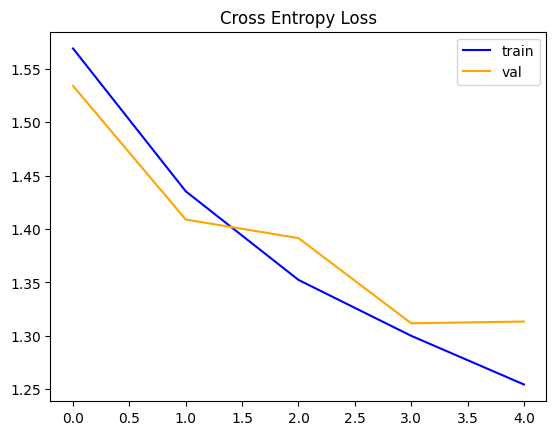

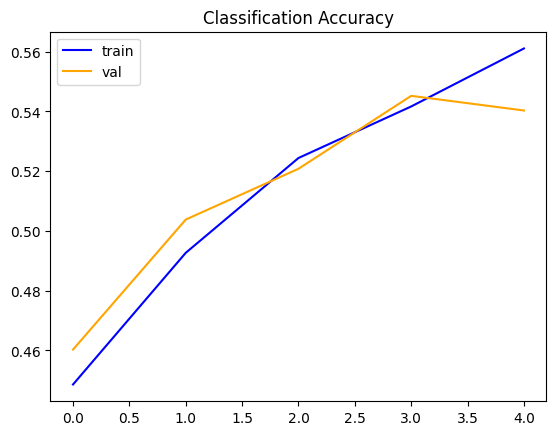

In [43]:
plots.plot_cross_entropy_loss(history)

plots.plot_classification_accuracy(history)

El coste podemos ver que es estable y es en el epoch 15 que se fija en un valor. Además la accuracy baila alrededor de 0.10. No se puede decir que sea un modelo muy bueno.

Veamos que tipo de predicciones estoy obteniendo sobre el conjunto de test (vamos a pintar las imagenes y sus clasificaciones)

In [45]:
predictions = model.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Una de las ventajas de Python es que hay montones de funciones y código realizado por terceras personas. Aquí me he fusilado unas bonitas funciones (que he adaptado un poco a mis necesidades) para poder pintar las imagenes, su label (ground truth) y las clasificaciones que hemos realizado.

Dibujamos las primeras imagenes, con las predicciones y sus valores reales (un total de 20 imagenes, para no abusar de vuestros laptops)

Coloreamos las prediciones correctas en azul y los fallos en rojo. Aunque primero he impreso las etiquetas para que tengamos una referencia al grafico.

0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


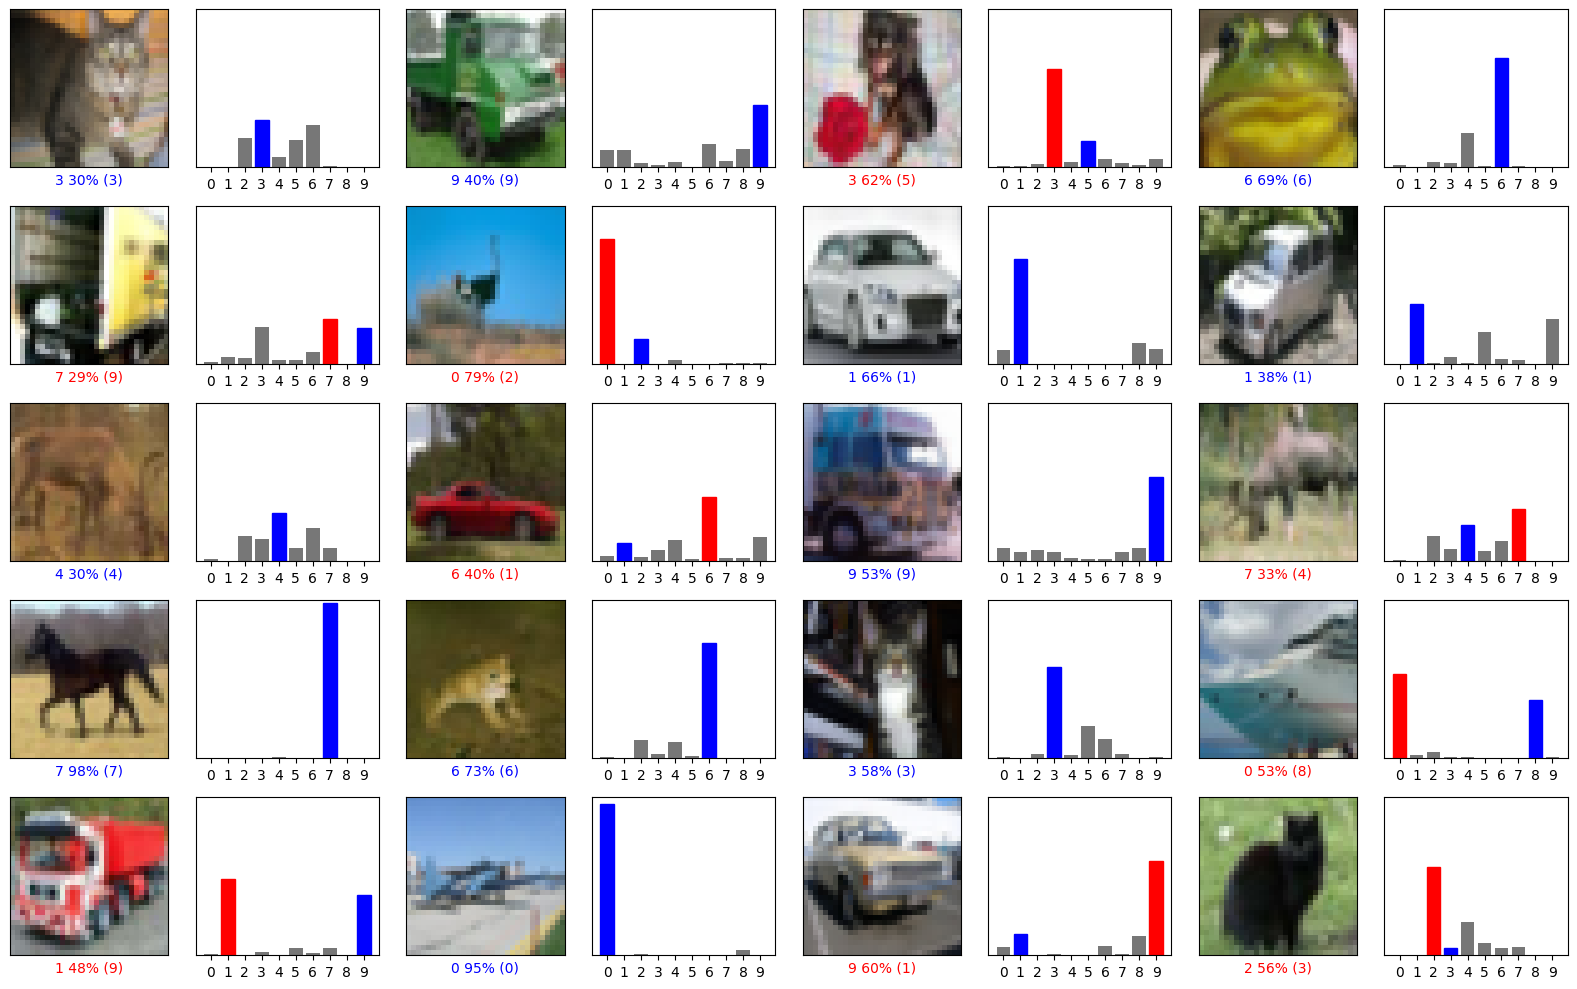

In [ ]:
i = 0
for l in utils.cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))

for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plots.plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plots.plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()

## 7. Guardamos el modelo para futuras evaluaciones

Id cambiando los nombres del archivo para ir guardando los diversos proyectos.
Aquí lo guardamos en "local", pero recordad que lo ideal es que lo guardeis en Google Drive (teneis que montar la unidad, fijar la ruta y allí guardar el modelo .h5)

In [ ]:
# ruta_googledrive = "/content/drive/MyDrive/" # A revisar en vuestra instancia
# model.save(ruta_googledrive+'cifar10_base_model.keras')

file_path = "models/"
model.save(file_path +'cifar10_base_model.keras')

# Proyecto 1 - Cambio a Layers/Capas

## 2. Arquitectura de red del modelo - Proyecto 1


Vamos añadir otro capa/layer para usar lo que aprendimos en la primera capa. 

In [ ]:
model_1 = ks.Sequential()
model_1.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_1.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_1.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_1.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_1.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_1.add(ks.layers.MaxPooling2D((2, 2)))

model_1.add(ks.layers.Flatten())
model_1.add(ks.layers.Dense(32, activation='relu'))
model_1.add(ks.layers.Dense(10, activation='softmax'))


In [ ]:
model_1.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,290 (333.16 KB)

 Trainable params: 85,290 (333.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_1.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
x_train_rows, y_train, x_test_rows, y_test =utils.load_data(data_dir)

In [ ]:
# Validamos el resultado
shapes.validar_shape(x_train_rows,y_train,'train')
shapes.validar_shape(x_test_rows,y_test,'test')

Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [ ]:
x_train =  []
x_test =  []

for i in range(x_train_rows.shape[0]):
  x_train.append(utils.parse_record(x_train_rows[i]))

for i in range(x_test_rows.shape[0]):
  x_test.append(utils.parse_record(x_test_rows[i]))

x_train = np.array(x_train)
x_test = np.array(x_test)

In [ ]:
# Validamos el resultado
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
x_train_scaled, x_test_scaled = x_train / 255.0, x_test / 255.0

In [ ]:
# Validamos el resultado
print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
print('Number of labels: %s' % len(utils.cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


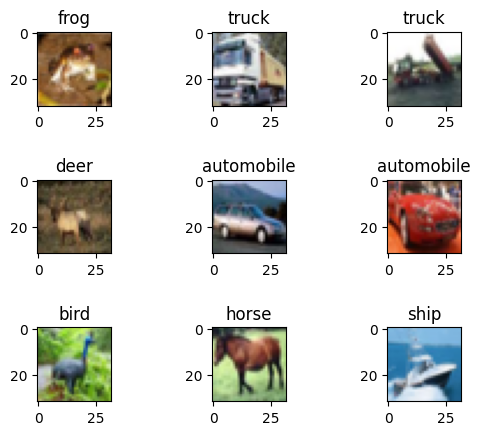

In [ ]:
# Pintemos una muestra de las las imagenes del dataset MNIST

print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

for i in range(9):

    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
    plt.title(utils.cifar10_labels[y_train[i]])

plt.subplots_adjust(hspace = 1)
plt.show()

In [ ]:
x_val_scaled = x_train_scaled[-10000:]
y_val = y_train[-10000:]

x_train_scaled = x_train_scaled[:-10000]
y_train = y_train[:-10000]


In [ ]:
# Validamos el resultado
print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))
print('Validation: X=%s, y=%s' % (x_val_scaled.shape, y_val.shape))

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
t = time.perf_counter()

In [ ]:
history = model_1.fit(x_train_scaled, y_train, epochs=20,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/20
11/79 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.7162 - loss: 0.8134

KeyboardInterrupt: 

Hemos podido mejorar el accuracy por 10 puntos usando otra capa.

In [ ]:
_, acc = model_1.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 66.550


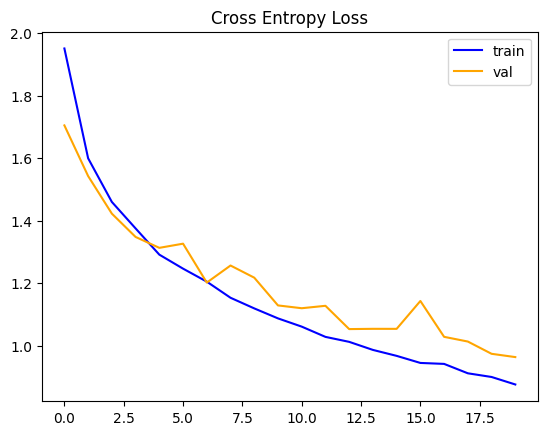

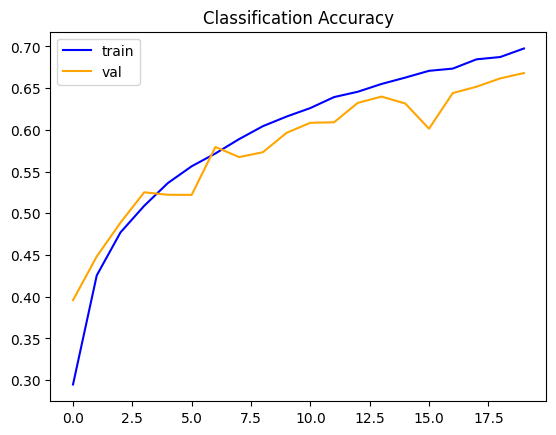

In [ ]:
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='val')
plt.legend()
plt.show()

plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='blue', label='train')
plt.plot(history.history['val_accuracy'], color='orange', label='val')
plt.legend()
plt.show()

In [ ]:
predictions = model_1.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


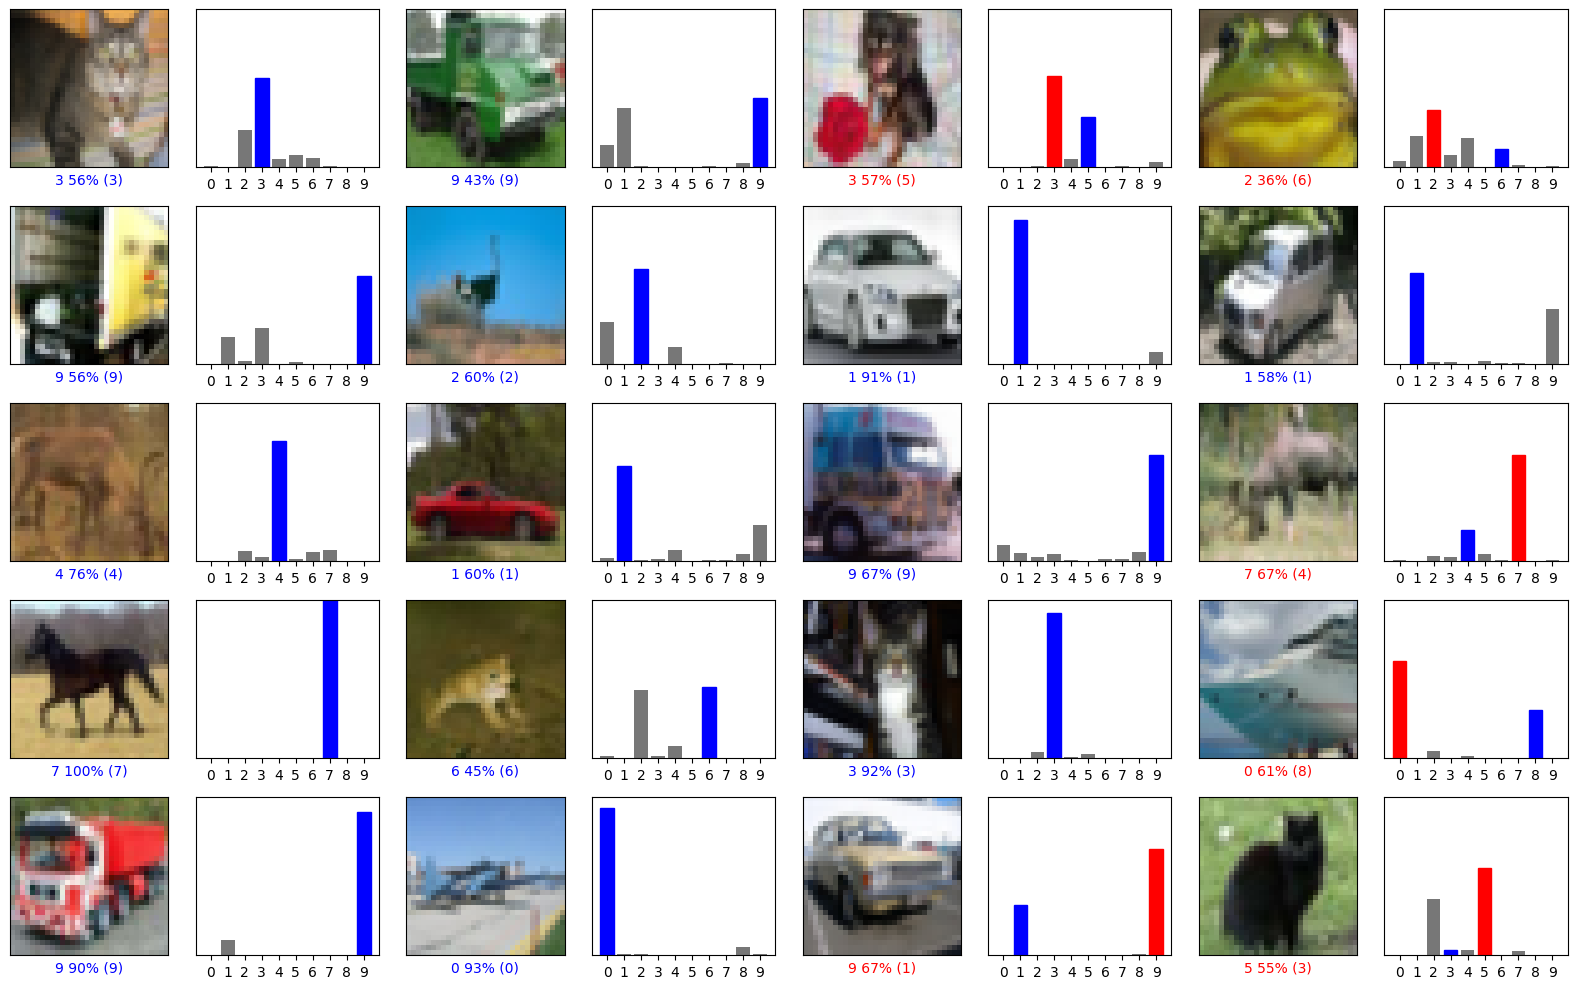

In [ ]:
i = 0
for l in utils.cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()

El modelo acierta el gato, que no pudo acertar en el Proyecto 0.

In [ ]:
# ruta_googledrive = "/content/drive/MyDrive/" # A revisar en vuestra instancia
# model.save(ruta_googledrive+'cifar10_base_model.keras')

# file_path = "models/"

model_1.save(file_path +'cifar10_model_1.keras')

# Proyecto 2 - Cambio a Layers/Capa (MAS CAPAS)

## 2. Arquitectura de red del modelo - Proyecto 2


In [ ]:
model_2 = ks.Sequential()
model_2.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.MaxPooling2D((2, 2)))

# Otra capa encima de esa
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.MaxPooling2D((2, 2)))

model_2.add(ks.layers.Flatten())
model_2.add(ks.layers.Dense(32, activation='relu'))
model_2.add(ks.layers.Dense(10, activation='softmax'))


In [ ]:
model_2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,634 (213.41 KB)

 Trainable params: 54,634 (213.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_2.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
x_train_rows, y_train, x_test_rows, y_test =utils.load_data(data_dir)

# Validamos el resultado
print('---Shape inicial---')
shapes.validar_shape(x_train_rows,y_train,'train')
shapes.validar_shape(x_test_rows,y_test,'test')

---Shape inicial---
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [ ]:
x_train =  []
x_test =  []

for i in range(x_train_rows.shape[0]):
  x_train.append(utils.parse_record(x_train_rows[i]))

for i in range(x_test_rows.shape[0]):
  x_test.append(utils.parse_record(x_test_rows[i]))

x_train = np.array(x_train)
x_test = np.array(x_test)

In [ ]:
# Validamos el resultado
print('---Shape despues de convertir con parse_record()---')
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

---Shape despues de convertir con parse_record()---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
x_train_scaled, x_test_scaled = x_train / 255.0, x_test / 255.0

# Validamos el resultado
print('---Shape despues de escalar---')

print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))

---Shape despues de escalar---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
print('Number of labels: %s' % len(utils.cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


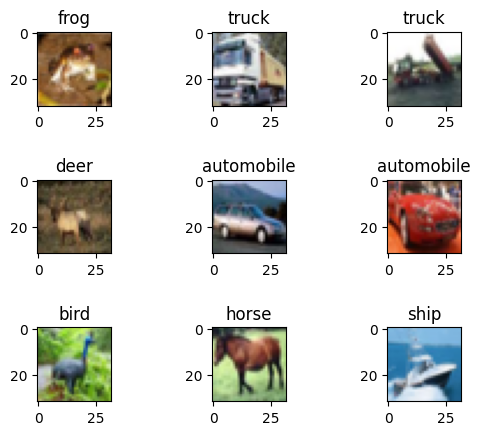

In [ ]:
# Pintemos una muestra de las las imagenes del dataset MNIST

print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

for i in range(9):

    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
    plt.title(utils.cifar10_labels[y_train[i]])

plt.subplots_adjust(hspace = 1)
plt.show()

In [ ]:
x_val_scaled = x_train_scaled[-10000:]
y_val = y_train[-10000:]

x_train_scaled = x_train_scaled[:-10000]
y_train = y_train[:-10000]


In [ ]:
history = model_2.fit(x_train_scaled, y_train, epochs=20,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.2805 - loss: 1.9800 - val_accuracy: 0.3869 - val_loss: 1.6940
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.4191 - loss: 1.5920 - val_accuracy: 0.4423 - val_loss: 1.5213
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.4658 - loss: 1.4665 - val_accuracy: 0.4767 - val_loss: 1.4456
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.4961 - loss: 1.3911 - val_accuracy: 0.5101 - val_loss: 1.3535
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.5262 - loss: 1.3187 - val_accuracy: 0.5368 - val_loss: 1.3018
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.5490 - loss: 1.2537 - val_accuracy: 0.5482 - val_loss: 1.2646
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.5675 - loss: 1.2089 - val_accuracy: 0.5673 - val_loss: 1.2150
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.5848 - loss: 1.1624 - val_accuracy: 0.54

In [ ]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:27:07.545572


In [ ]:
_, acc = model_2.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 65.560


Ha empeorado con otra capa, sugeriendo que no aportó mucho esta nueva capa. Tal vez hay que aumentar el número de epochs o hacer otros cambios.

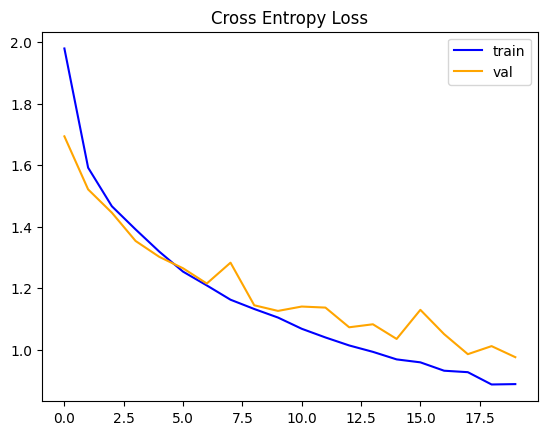

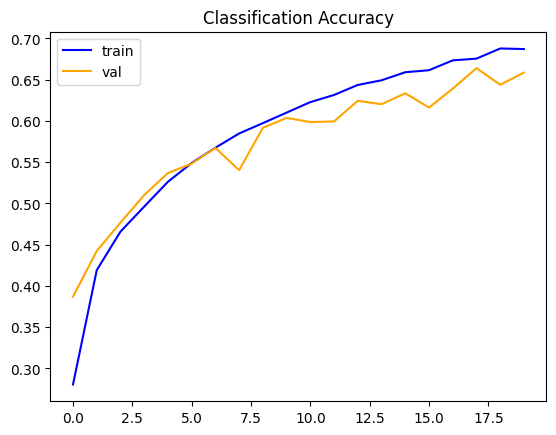

In [ ]:
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='val')
plt.legend()
plt.show()

plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='blue', label='train')
plt.plot(history.history['val_accuracy'], color='orange', label='val')
plt.legend()
plt.show()

In [ ]:
predictions = model_2.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


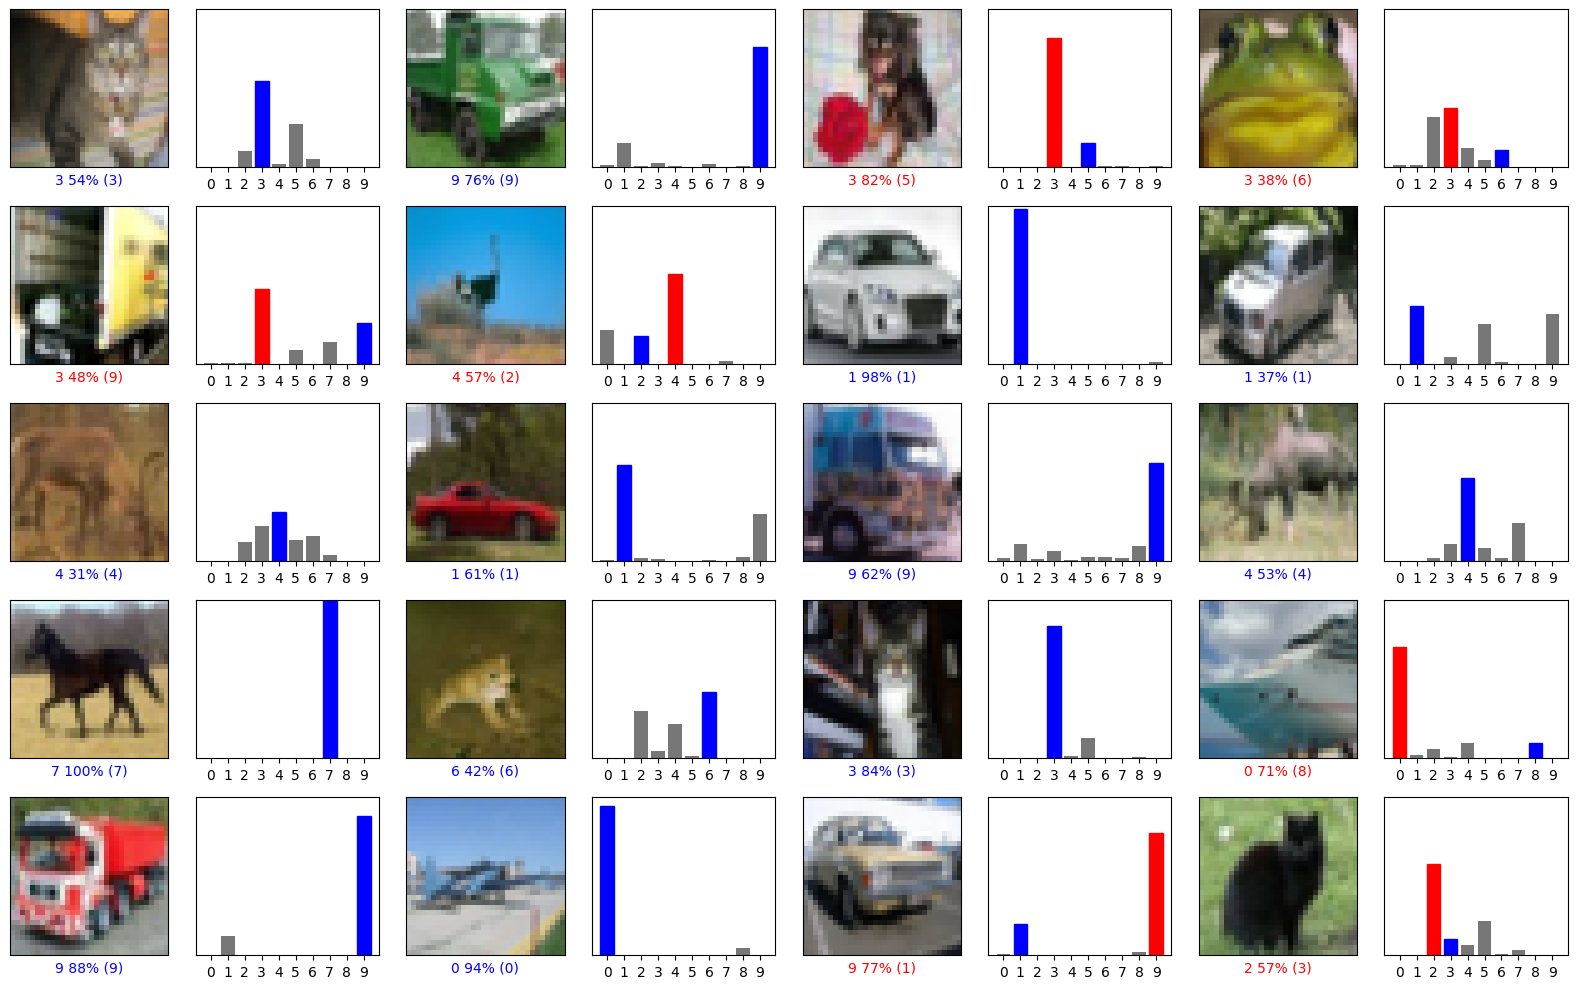

In [ ]:
i = 0
for l in utils.cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()

Sigue equivocandose en las mismas del Proyecto 1

In [ ]:
model_2.save(file_path +'cifar10_model_2.keras')

# Proyecto 3 - Cambio a Layers/Capa con más epochs

## 2. Arquitectura de red del modelo - Proyecto 3


In [ ]:
model_3 = ks.Sequential()
model_3.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_3.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_3.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.MaxPooling2D((2, 2)))

# Otra capa encima de esa
model_3.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.MaxPooling2D((2, 2)))

model_3.add(ks.layers.Flatten())
model_3.add(ks.layers.Dense(32, activation='relu'))
model_3.add(ks.layers.Dense(10, activation='softmax'))


In [ ]:
model_3.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,634 (213.41 KB)

 Trainable params: 54,634 (213.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_3.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
x_train_rows, y_train, x_test_rows, y_test =utils.load_data(data_dir)

# Validamos el resultado
print('---Shape inicial---')
shapes.validar_shape(x_train_rows,y_train,'train')
shapes.validar_shape(x_test_rows,y_test,'test')

---Shape inicial---
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [ ]:
x_train =  []
x_test =  []

for i in range(x_train_rows.shape[0]):
  x_train.append(utils.parse_record(x_train_rows[i]))

for i in range(x_test_rows.shape[0]):
  x_test.append(utils.parse_record(x_test_rows[i]))

x_train = np.array(x_train)
x_test = np.array(x_test)

In [ ]:
# Validamos el resultado
print('---Shape despues de convertir con parse_record()---')
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

---Shape despues de convertir con parse_record()---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
x_train_scaled, x_test_scaled = x_train / 255.0, x_test / 255.0

# Validamos el resultado
print('---Shape despues de escalar---')

print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))

---Shape despues de escalar---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
print('Number of labels: %s' % len(utils.cifar10_labels))

Number of labels: 10


In [ ]:
# Pintemos una muestra de las las imagenes del dataset MNIST

print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

for i in range(9):

    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
    plt.title(utils.cifar10_labels[y_train[i]])

plt.subplots_adjust(hspace = 1)
plt.show()

In [ ]:
x_val_scaled = x_train_scaled[-10000:]
y_val = y_train[-10000:]

x_train_scaled = x_train_scaled[:-10000]
y_train = y_train[:-10000]


In [ ]:
history = model_3.fit(x_train_scaled, y_train, epochs=30,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.3338 - loss: 1.8353 - val_accuracy: 0.3856 - val_loss: 1.7199
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.4290 - loss: 1.5774 - val_accuracy: 0.4573 - val_loss: 1.4991
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.4775 - loss: 1.4510 - val_accuracy: 0.4872 - val_loss: 1.4261
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.5095 - loss: 1.3657 - val_accuracy: 0.5246 - val_loss: 1.3331
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.5370 - loss: 1.2976 - val_accuracy: 0.5179 - val_loss: 1.3491
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.5582 - loss: 1.2388 - val_accuracy: 0.5524 - val_loss: 1.2576
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.5782 - loss: 1.1872 - val_accuracy: 0.5658 - val_loss: 1.2307
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.5950 - loss: 1.1458 - val_accuracy: 0.590

In [ ]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 1:12:40.401795


In [ ]:
_, acc = model_3.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 69.510


Ha subido el accuracy con más epochs y capas. 

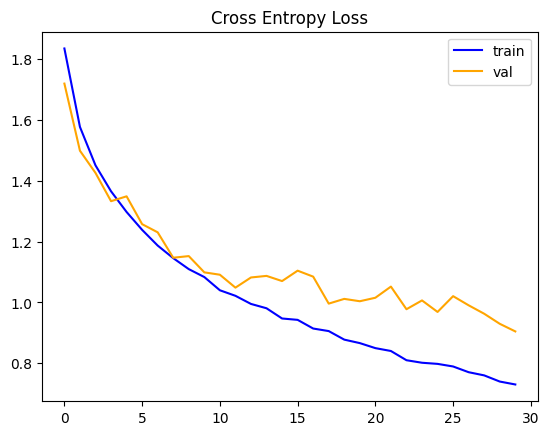

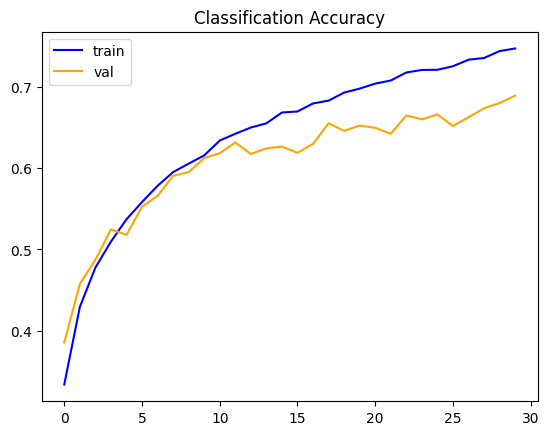

In [ ]:
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='val')
plt.legend()
plt.show()

plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='blue', label='train')
plt.plot(history.history['val_accuracy'], color='orange', label='val')
plt.legend()
plt.show()

Parece que se estabilisa después de 25 epochs. Con más epochs, podría ir mejorando o tal vez correr riesgo de overfitting.

In [ ]:
predictions = model_3.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


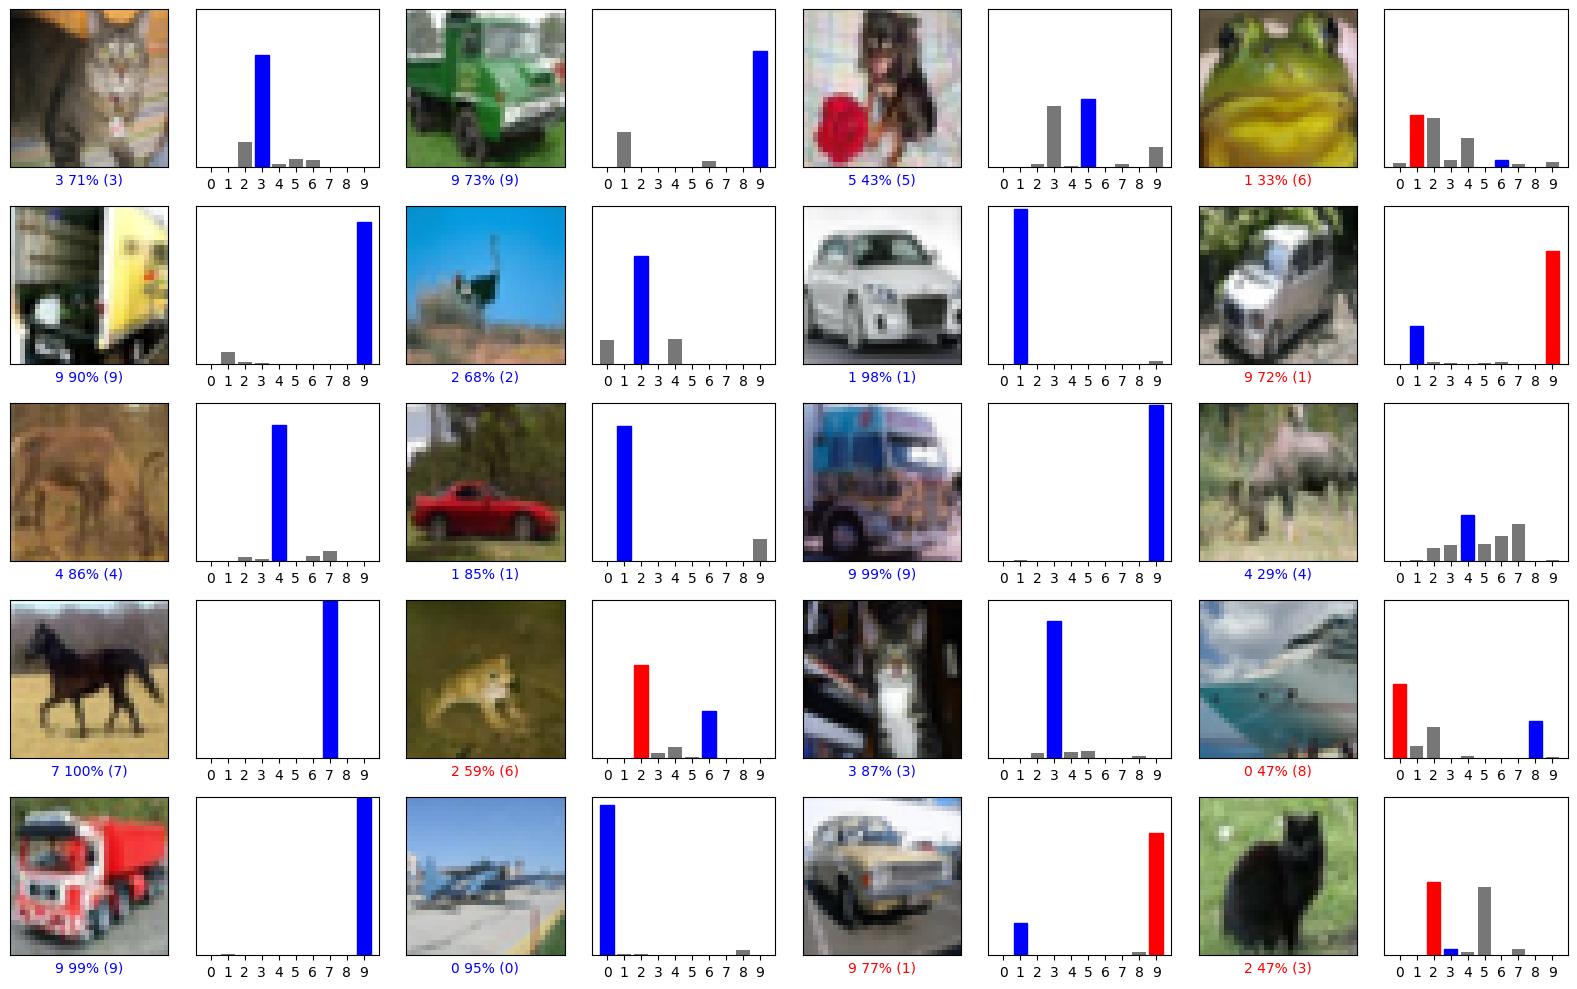

In [ ]:
i = 0
for l in utils.cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()

Parece que autos todavía causan una mica de problemas.

In [ ]:
model_3.save(file_path +'cifar10_model_3.keras')

# Proyecto 4 - Cambio a Capa/Inputs

## 2. Arquitectura de red del modelo - Proyecto 4


In [ ]:
model_4 = ks.Sequential()
model_4.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.MaxPooling2D((2, 2)))

# Otra capa encima de esa
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.MaxPooling2D((2, 2)))

# 
model_4.add(ks.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model_4.add(ks.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model_4.add(ks.layers.MaxPooling2D((2, 2)))

model_4.add(ks.layers.Flatten())
# model_4.add(ks.layers.Dense(32, activation='relu'))

# Aumentando densidad para evitar perder mucha información
model_4.add(ks.layers.Dense(128, activation='relu'))
model_4.add(ks.layers.Dense(10, activation='softmax'))


In [ ]:
model_4.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,498 (498.04 KB)

 Trainable params: 127,498 (498.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_4.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
x_train_rows, y_train, x_test_rows, y_test =utils.load_data(data_dir)

# Validamos el resultado
print('---Shape inicial---')
shapes.validar_shape(x_train_rows,y_train,'train')
shapes.validar_shape(x_test_rows,y_test,'test')

---Shape inicial---
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [ ]:
x_train =  []
x_test =  []

for i in range(x_train_rows.shape[0]):
  x_train.append(utils.parse_record(x_train_rows[i]))

for i in range(x_test_rows.shape[0]):
  x_test.append(utils.parse_record(x_test_rows[i]))

x_train = np.array(x_train)
x_test = np.array(x_test)

In [ ]:
# Validamos el resultado
print('---Shape despues de convertir con parse_record()---')
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

---Shape despues de convertir con parse_record()---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
x_train_scaled, x_test_scaled = x_train / 255.0, x_test / 255.0

# Validamos el resultado
print('---Shape despues de escalar---')

print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))

---Shape despues de escalar---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
print('Number of labels: %s' % len(utils.cifar10_labels))

Number of labels: 10


In [ ]:
x_val_scaled = x_train_scaled[-10000:]
y_val = y_train[-10000:]

x_train_scaled = x_train_scaled[:-10000]
y_train = y_train[:-10000]


In [ ]:
history = model_4.fit(x_train_scaled, y_train, epochs=30,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.8073 - loss: 0.5506 - val_accuracy: 0.6656 - val_loss: 1.0646
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.8122 - loss: 0.5306 - val_accuracy: 0.6760 - val_loss: 1.0199
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.8183 - loss: 0.5188 - val_accuracy: 0.6928 - val_loss: 0.9686
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.8219 - loss: 0.5100 - val_accuracy: 0.6833 - val_loss: 1.0272
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.8338 - loss: 0.4719 - val_accuracy: 0.6964 - val_loss: 0.9858
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.8408 - loss: 0.4522 - val_accuracy: 0.6864 - val_loss: 1.0209
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.8493 - loss: 0.4279 - val_accuracy: 0.6889 - val_loss: 1.0391
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.8587 - loss: 0.4076 - val_accuracy: 0.

In [ ]:
_, acc = model_4.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 67.730


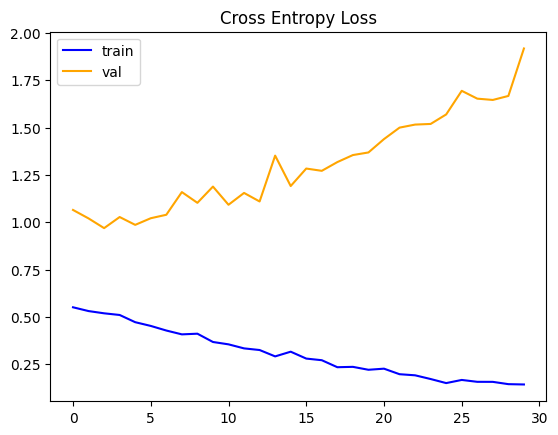

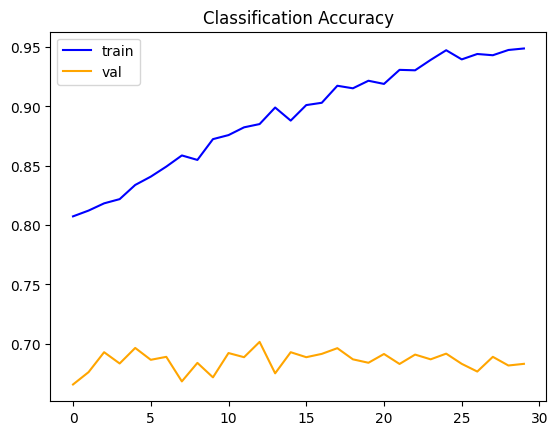

In [ ]:
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='val')
plt.legend()
plt.show()

plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='blue', label='train')
plt.plot(history.history['val_accuracy'], color='orange', label='val')
plt.legend()
plt.show()

Overfitting.

In [ ]:
predictions = model_4.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


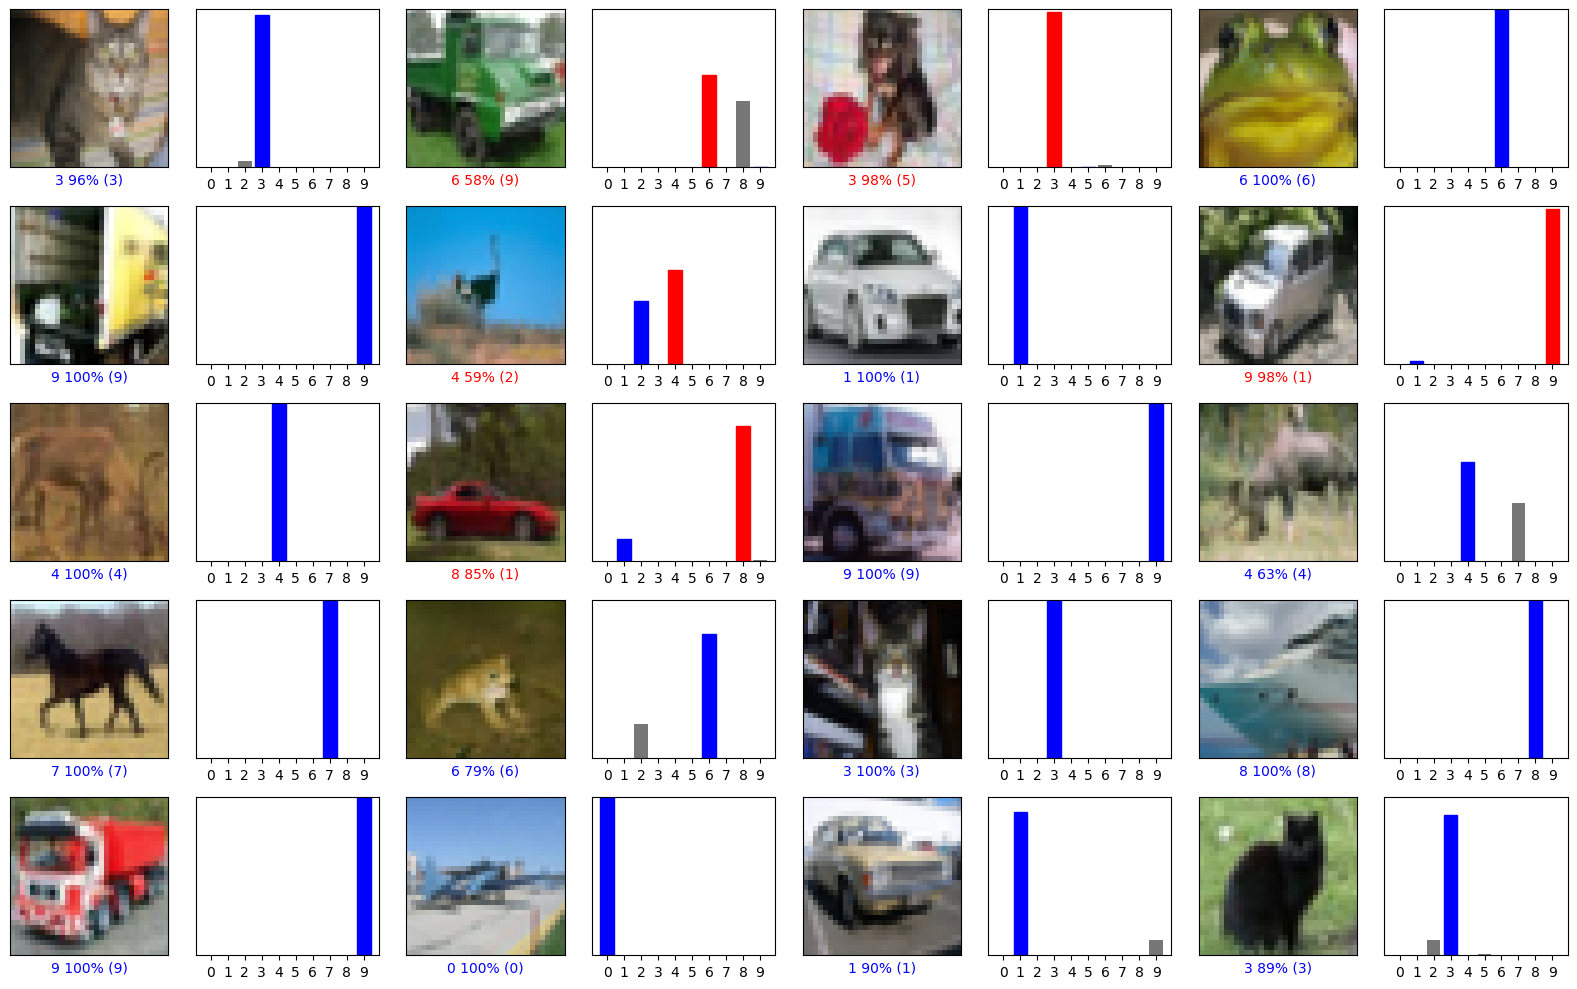

In [ ]:
i = 0
for l in utils.cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()

Vemos que sabe los imagenes super bien, pero todavía falla.

In [ ]:
model_4.save(file_path +'cifar10_model_4.keras')

# Proyecto 5 - Cambio a Capa/Inputs

## 2. Arquitectura de red del modelo - Proyecto 5


In [ ]:
model_5 = ks.Sequential()
model_5.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.BatchNormalization())
model_5.add(ks.layers.MaxPooling2D((2, 2)))
model_5.add(ks.layers.Dropout(0.25))

# Nueva capa
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.BatchNormalization())
model_5.add(ks.layers.MaxPooling2D((2, 2)))
model_5.add(ks.layers.Dropout(0.25)) 

# Otra capa encima de esa
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.BatchNormalization())
model_5.add(ks.layers.MaxPooling2D((2, 2)))
model_5.add(ks.layers.Dropout(0.25)) 

model_5.add(ks.layers.Flatten())
model_5.add(ks.layers.Dense(128, activation='relu'))
model_5.add(ks.layers.Dropout(0.5))
model_5.add(ks.layers.Dense(10, activation='softmax'))

In [ ]:
model_5.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
x_train_rows, y_train, x_test_rows, y_test =utils.load_data(data_dir)

# Validamos el resultado
print('---Shape inicial---')
shapes.validar_shape(x_train_rows,y_train,'train')
shapes.validar_shape(x_test_rows,y_test,'test')

---Shape inicial---
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [ ]:
x_train =  []
x_test =  []

for i in range(x_train_rows.shape[0]):
  x_train.append(utils.parse_record(x_train_rows[i]))

for i in range(x_test_rows.shape[0]):
  x_test.append(utils.parse_record(x_test_rows[i]))

x_train = np.array(x_train)
x_test = np.array(x_test)

In [ ]:
# Validamos el resultado
print('---Shape despues de convertir con parse_record()---')
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

---Shape despues de convertir con parse_record()---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
x_train_scaled, x_test_scaled = x_train / 255.0, x_test / 255.0

# Validamos el resultado
print('---Shape despues de escalar---')

print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))

---Shape despues de escalar---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
print('Number of labels: %s' % len(utils.cifar10_labels))

Number of labels: 10


In [ ]:
x_val_scaled = x_train_scaled[-10000:]
y_val = y_train[-10000:]

x_train_scaled = x_train_scaled[:-10000]
y_train = y_train[:-10000]


In [ ]:
# Volvemos a 20 epochs
history = model_5.fit(x_train_scaled, y_train, epochs=20,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 169ms/step - accuracy: 0.2123 - loss: 2.2269 - val_accuracy: 0.0997 - val_loss: 3.1940
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.3362 - loss: 1.7745 - val_accuracy: 0.1006 - val_loss: 3.8317
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.4005 - loss: 1.6156 - val_accuracy: 0.1002 - val_loss: 4.7338
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.4467 - loss: 1.5151 - val_accuracy: 0.1095 - val_loss: 4.6247
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.4818 - loss: 1.4268 - val_accuracy: 0.1913 - val_loss: 3.5712
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 0.5138 - loss: 1.3435 - val_accuracy: 0.3205 - val_loss: 2.3119
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.5383 - loss: 1.2884 - val_accuracy: 0.3996 - val_loss: 1.9479
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.5603 - loss: 1.2249 - val_accu

In [ ]:
_, acc = model_5.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 67.210


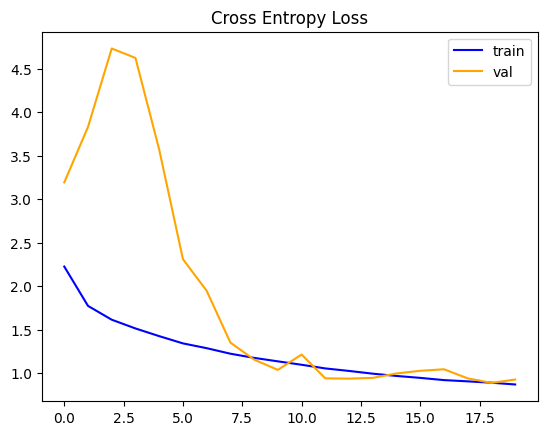

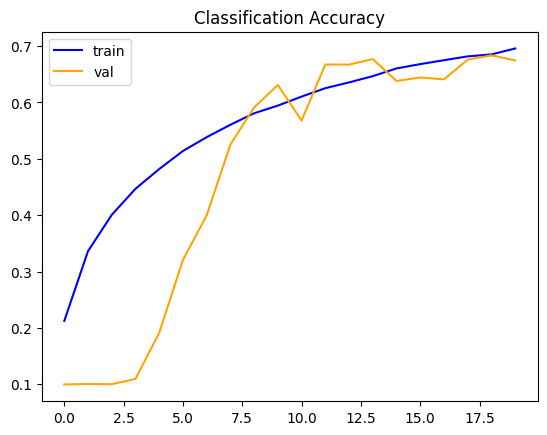

In [ ]:
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='val')
plt.legend()
plt.show()

plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='blue', label='train')
plt.plot(history.history['val_accuracy'], color='orange', label='val')
plt.legend()
plt.show()

In [ ]:
predictions = model_5.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


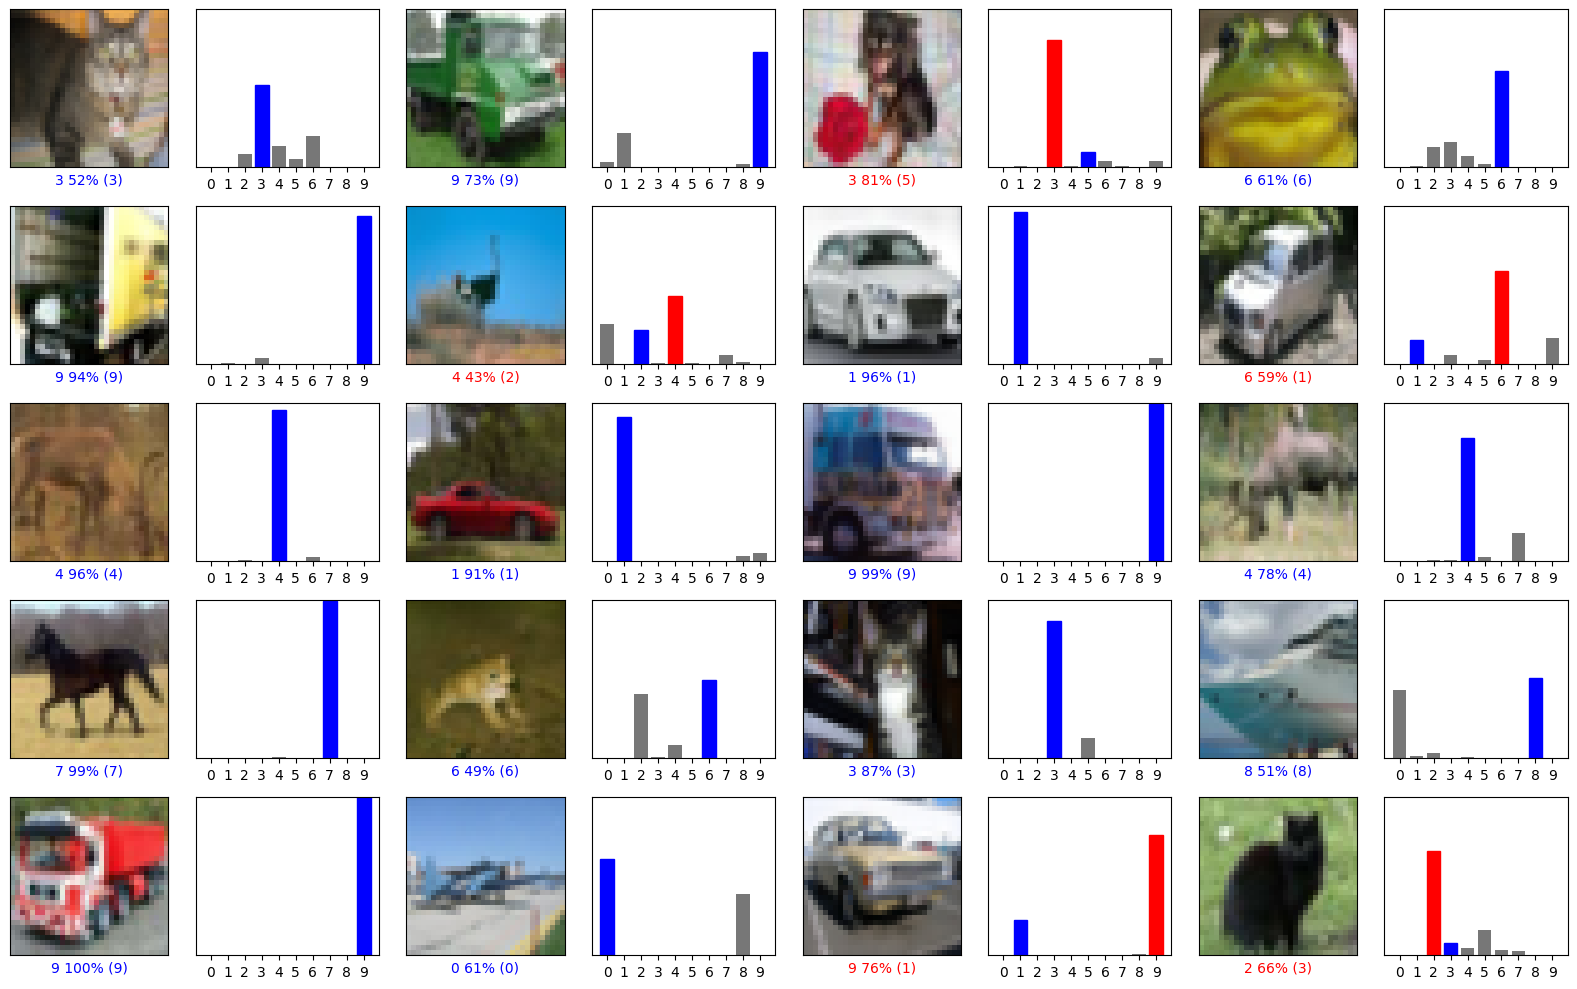

In [ ]:
i = 0
for l in utils.cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()

In [ ]:
model_5.save(file_path +'cifar10_model_5.keras')

<!-- Dropout  -->

# Note: Dropout and Using 128 filters/parameters.

In [22]:
model_6 = ks.Sequential()
model_6.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_6.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_6.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.MaxPooling2D((2, 2)))

# Otra capa encima de esa
model_6.add(ks.layers.Conv2D(128, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.Conv2D(128, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.MaxPooling2D((2, 2)))

model_6.add(ks.layers.Flatten())
model_6.add(ks.layers.Dense(128, activation='relu'))
model_6.add(ks.layers.Dense(10, activation='softmax'))


In [23]:
model_6.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,322 (2.06 MB)

 Trainable params: 541,322 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model_6.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
x_train_rows, y_train, x_test_rows, y_test =utils.load_data(data_dir)

# Validamos el resultado
print('---Shape inicial---')
shapes.validar_shape(x_train_rows,y_train,'train')
shapes.validar_shape(x_test_rows,y_test,'test')

---Shape inicial---
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [ ]:
x_train =  []
x_test =  []

for i in range(x_train_rows.shape[0]):
  x_train.append(utils.parse_record(x_train_rows[i]))

for i in range(x_test_rows.shape[0]):
  x_test.append(utils.parse_record(x_test_rows[i]))

x_train = np.array(x_train)
x_test = np.array(x_test)

In [27]:
# Validamos el resultado
print('---Shape despues de convertir con parse_record()---')
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

---Shape despues de convertir con parse_record()---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [28]:
x_train_scaled, x_test_scaled = x_train / 255.0, x_test / 255.0

# Validamos el resultado
print('---Shape despues de escalar---')

print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))

---Shape despues de escalar---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
print('Number of labels: %s' % len(utils.cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


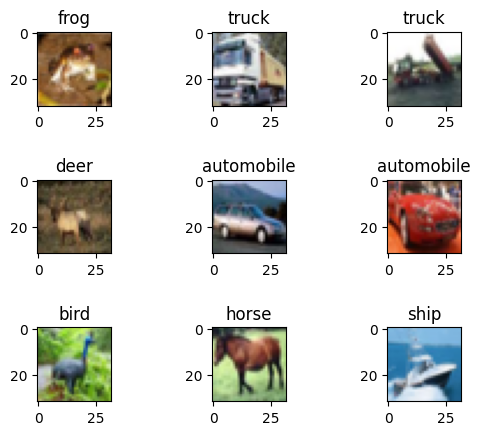

In [ ]:
# Pintemos una muestra de las las imagenes del dataset MNIST

print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

for i in range(9):

    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
    plt.title(utils.cifar10_labels[y_train[i]])

plt.subplots_adjust(hspace = 1)
plt.show()

In [31]:
x_val_scaled = x_train_scaled[-10000:]
y_val = y_train[-10000:]

x_train_scaled = x_train_scaled[:-10000]
y_train = y_train[:-10000]


In [32]:
history = model_6.fit(x_train_scaled, y_train, epochs=30,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 265ms/step - accuracy: 0.3358 - loss: 1.8148 - val_accuracy: 0.4191 - val_loss: 1.6325
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 260ms/step - accuracy: 0.4909 - loss: 1.4097 - val_accuracy: 0.4732 - val_loss: 1.4935
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - accuracy: 0.5608 - loss: 1.2267 - val_accuracy: 0.5671 - val_loss: 1.2146
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 252ms/step - accuracy: 0.6193 - loss: 1.0800 - val_accuracy: 0.6269 - val_loss: 1.0552
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.6610 - loss: 0.9702 - val_accuracy: 0.6501 - val_loss: 0.9854
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - accuracy: 0.6894 - loss: 0.8909 - val_accuracy: 0.6778 - val_loss: 0.9213
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.7101 - loss: 0.8291 - val_accuracy: 0.6853 - val_loss: 0.9052
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 252ms/step - accuracy: 0.7378 - loss: 0.7532 - val_accu

In [33]:
_, acc = model_6.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 72.530


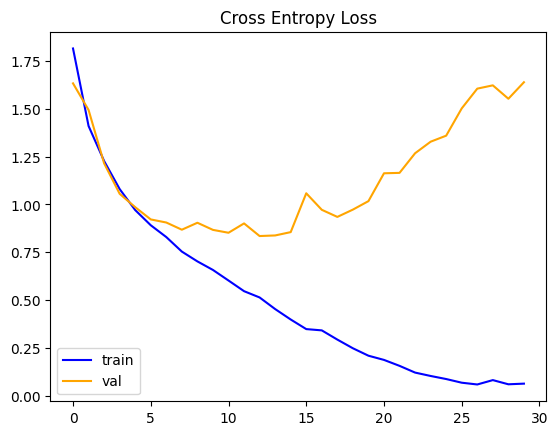

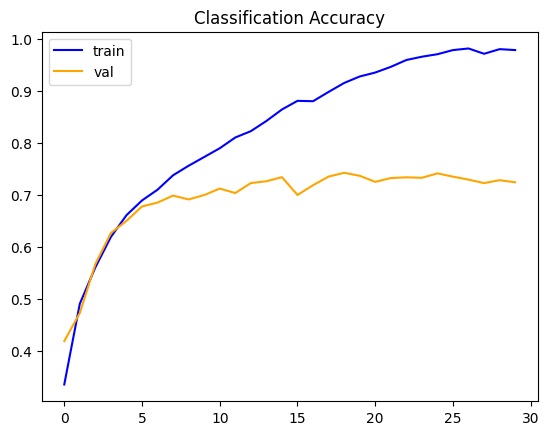

In [34]:
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='val')
plt.legend()
plt.show()

plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='blue', label='train')
plt.plot(history.history['val_accuracy'], color='orange', label='val')
plt.legend()
plt.show()

Ha mejorado el modelo. Podemos hacer otra ronda de regularización, y después augmentación de datos. 

In [35]:
predictions = model_6.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


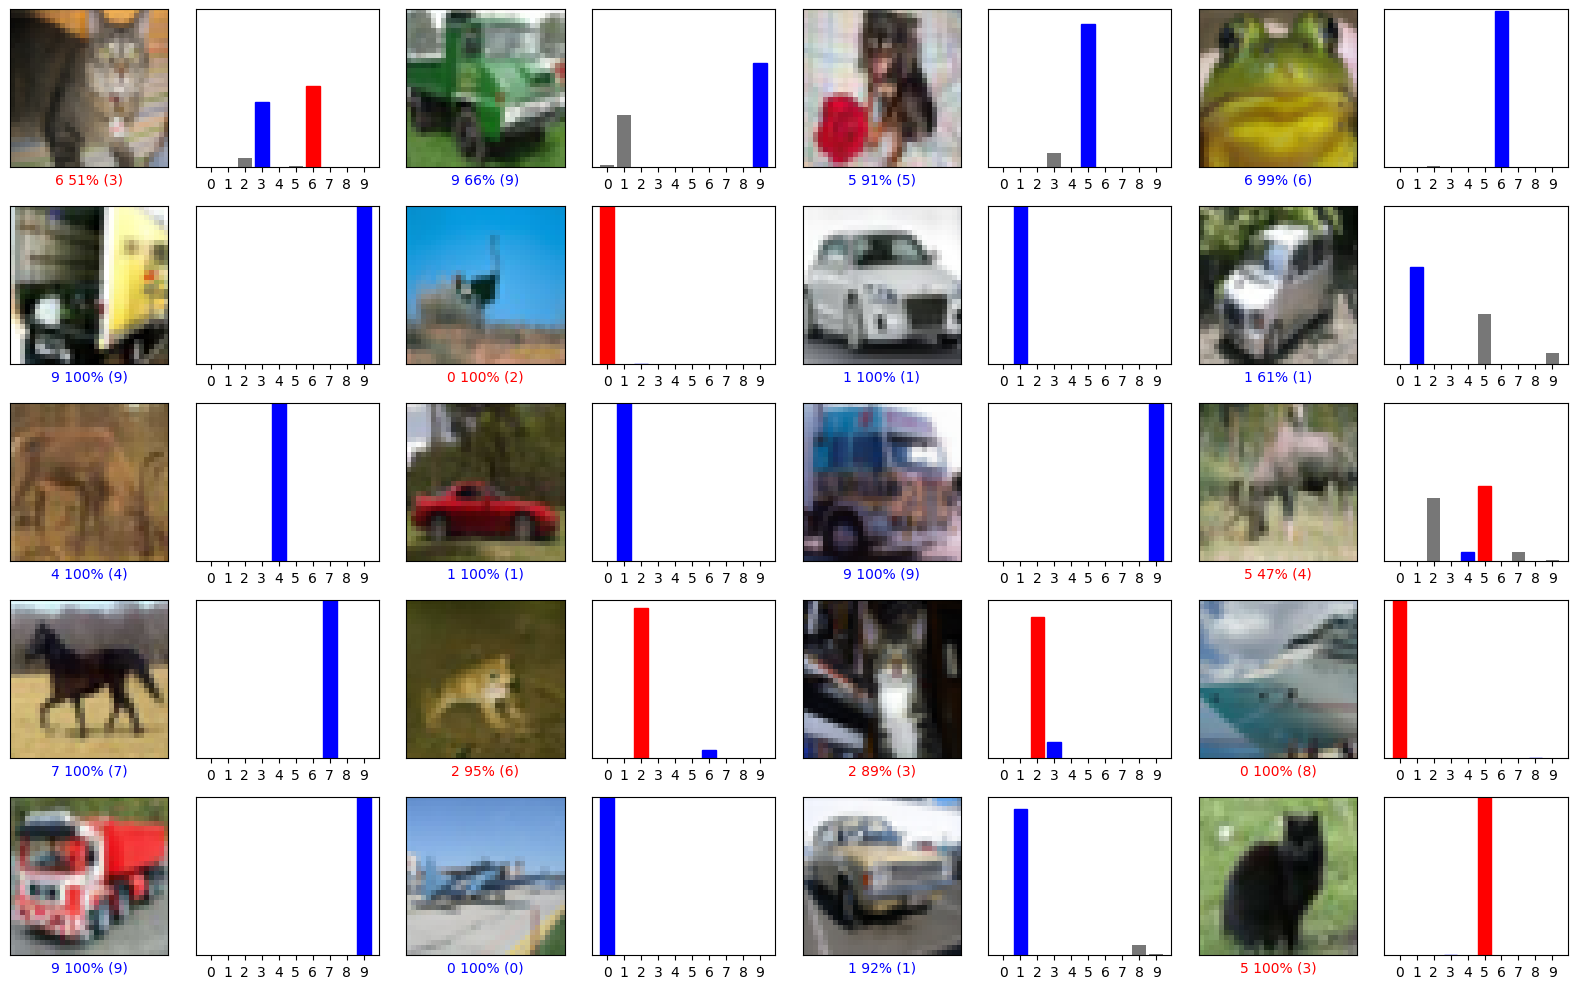

In [ ]:
i = 0
for l in utils.cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()

In [41]:
model_6.save(file_path +'cifar10_model_6.keras')

# Proyecto 7 - Cambio a Dropout

## 2. Arquitectura de red del modelo - Proyecto 7


In [42]:
model_7 = ks.Sequential()
model_7.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_7.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_7.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.MaxPooling2D((2, 2)))
model_7.add(ks.layers.Dropout(0.15)) 

# Otra capa encima de esa
model_7.add(ks.layers.Conv2D(128, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.Conv2D(128, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.MaxPooling2D((2, 2)))
model_7.add(ks.layers.Dropout(0.15)) 

model_7.add(ks.layers.Flatten())
model_7.add(ks.layers.Dense(128, activation='relu'))
model_7.add(ks.layers.Dropout(0.3))
model_7.add(ks.layers.Dense(10, activation='softmax'))


In [43]:
model_7.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,322 (2.06 MB)

 Trainable params: 541,322 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model_7.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
x_train_rows, y_train, x_test_rows, y_test =utils.load_data(data_dir)

# Validamos el resultado
print('---Shape inicial---')
shapes.validar_shape(x_train_rows,y_train,'train')
shapes.validar_shape(x_test_rows,y_test,'test')

---Shape inicial---
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [ ]:
x_train =  []
x_test =  []

for i in range(x_train_rows.shape[0]):
  x_train.append(utils.parse_record(x_train_rows[i]))

for i in range(x_test_rows.shape[0]):
  x_test.append(utils.parse_record(x_test_rows[i]))

x_train = np.array(x_train)
x_test = np.array(x_test)

In [47]:
# Validamos el resultado
print('---Shape despues de convertir con parse_record()---')
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

---Shape despues de convertir con parse_record()---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [48]:
x_train_scaled, x_test_scaled = x_train / 255.0, x_test / 255.0

# Validamos el resultado
print('---Shape despues de escalar---')

print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))

---Shape despues de escalar---
Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
print('Number of labels: %s' % len(utils.cifar10_labels))

Number of labels: 10


In [51]:
x_val_scaled = x_train_scaled[-10000:]
y_val = y_train[-10000:]

x_train_scaled = x_train_scaled[:-10000]
y_train = y_train[:-10000]


In [52]:
history = model_7.fit(x_train_scaled, y_train, epochs=30,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step - accuracy: 0.2772 - loss: 1.9411 - val_accuracy: 0.4160 - val_loss: 1.6013
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 257ms/step - accuracy: 0.4302 - loss: 1.5548 - val_accuracy: 0.4878 - val_loss: 1.3999
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 262ms/step - accuracy: 0.5085 - loss: 1.3511 - val_accuracy: 0.5567 - val_loss: 1.2338
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 259ms/step - accuracy: 0.5566 - loss: 1.2413 - val_accuracy: 0.5776 - val_loss: 1.1738
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - accuracy: 0.5937 - loss: 1.1480 - val_accuracy: 0.6070 - val_loss: 1.0837
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.6225 - loss: 1.0696 - val_accuracy: 0.6630 - val_loss: 0.9596
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 269ms/step - accuracy: 0.6571 - loss: 0.9802 - val_accuracy: 0.6406 - val_loss: 1.0018
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.6720 - loss: 0.9349 - val_accu

In [53]:
_, acc = model_7.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 78.240


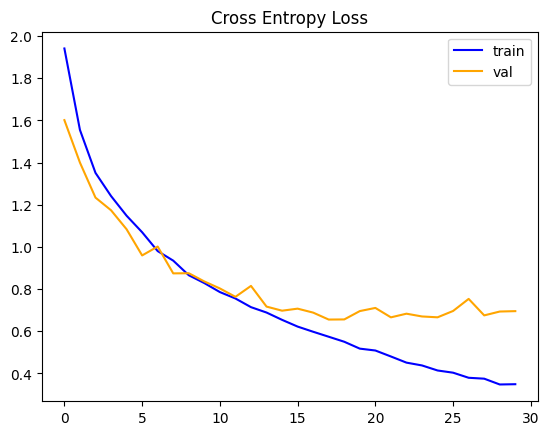

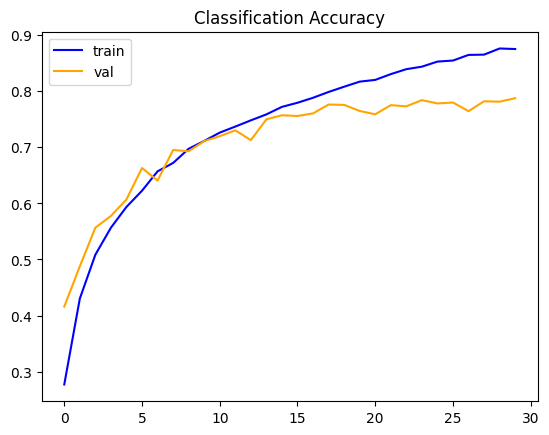

In [54]:
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='val')
plt.legend()
plt.show()

plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='blue', label='train')
plt.plot(history.history['val_accuracy'], color='orange', label='val')
plt.legend()
plt.show()

In [55]:
predictions = model_7.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


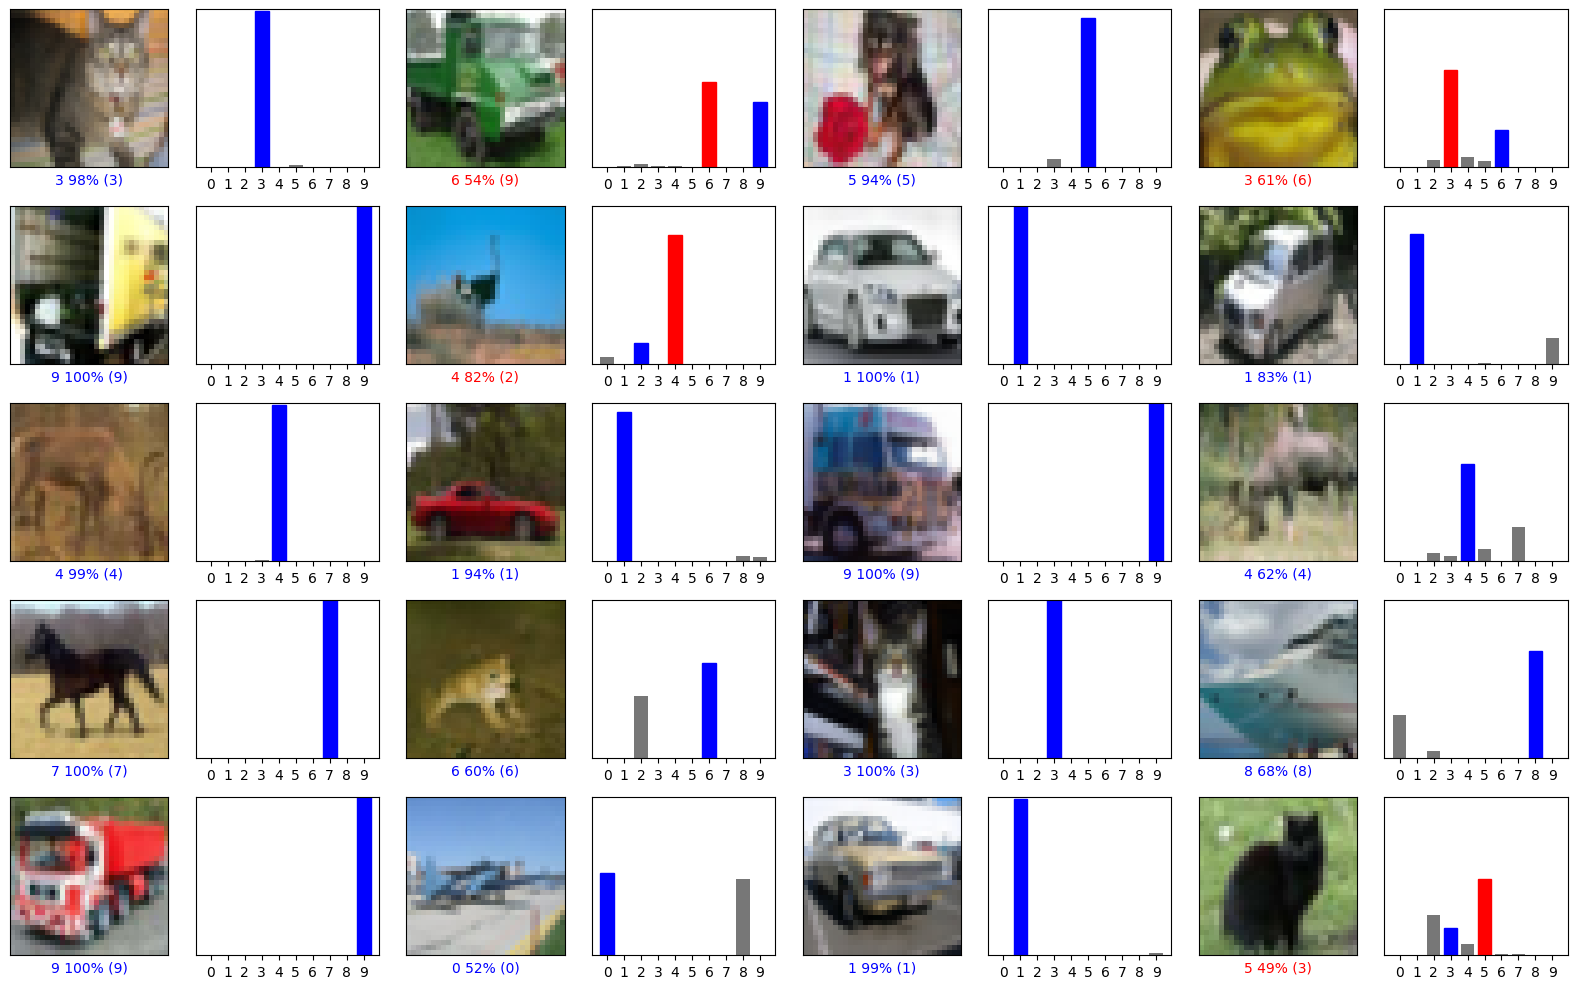

In [ ]:
i = 0
for l in utils.cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()

In [57]:
model_7.save(file_path +'cifar10_model_7.keras')

# Proyecto 8 - Con Data Augmentation

## 2. Arquitectura de red del modelo - Proyecto 8

In [59]:
train_augment = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

In [60]:
history_da = model_7.fit(
    train_augment.flow(x_train_scaled, y_train, batch_size=32),
    validation_data=(x_val_scaled, y_val),
    epochs=30,
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.6028 - loss: 1.1417 - val_accuracy: 0.7156 - val_loss: 0.8132
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.6611 - loss: 0.9804 - val_accuracy: 0.7101 - val_loss: 0.8532
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.6787 - loss: 0.9295 - val_accuracy: 0.7423 - val_loss: 0.7538
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.6900 - loss: 0.8978 - val_accuracy: 0.7244 - val_loss: 0.8134
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.7023 - loss: 0.8694 - val_accuracy: 0.7549 - val_loss: 0.7013
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.7109 - loss: 0.8459 - val_accuracy: 0.7434 - val_loss: 0.7313
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.7179 - loss: 0.8201 - val_accuracy: 0.7638 - val_loss: 0.6969
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.7248 -

In [63]:
_, acc = model_7.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 78.970


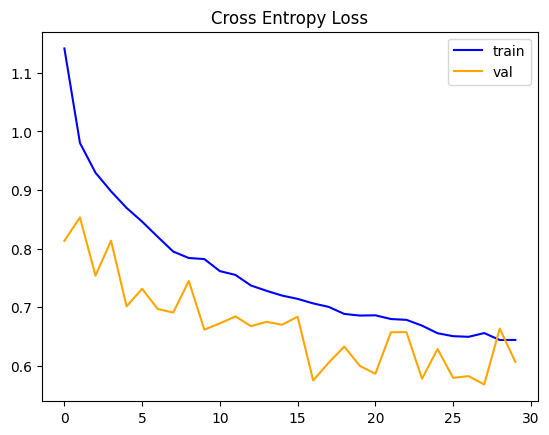

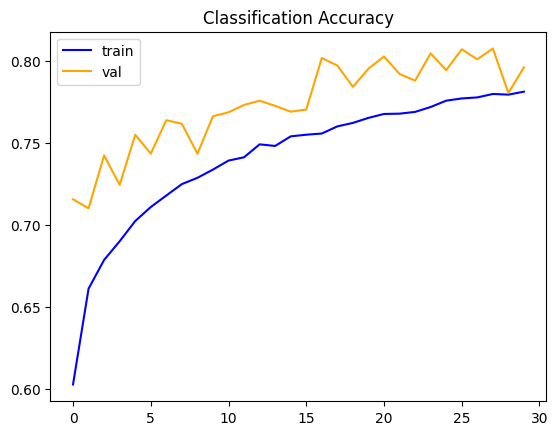

In [62]:
plt.title('Cross Entropy Loss')
plt.plot(history_da.history['loss'], color='blue', label='train')
plt.plot(history_da.history['val_loss'], color='orange', label='val')
plt.legend()
plt.show()

plt.title('Classification Accuracy')
plt.plot(history_da.history['accuracy'], color='blue', label='train')
plt.plot(history_da.history['val_accuracy'], color='orange', label='val')
plt.legend()
plt.show()

In [ ]:
predictions = model_7.predict(x_test_scaled)

Maybe more epochs needed.

In [ ]:
i = 0
for l in utils.cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()